# ADS-509 Assignment 2.1
## Text Cleaning and Exploration


In this assignment, you will use the HackerNews dataset created in the Module 1 assignment to:
- Clean, normalize, and tokenize text
- Explore and analyze text
- Vectorize text
- Perform basic sentiment analysis
  
If you are not confident in the quality of your own dataset from Module 1, there is a clean dataset available for your use in the assignment repository on GitHub.

## General Assignment Instructions

These instructions are included in every assignment, to remind you of the coding standards for the class. Feel free to delete this cell after reading it.

Work through this notebook as if it were a worksheet, completing the code sections marked with **TODO** in the cells provided. Similarly, written questions will be marked by a "Q:" and will have a corresponding "A:" spot for you to fill in with your answers. **Make sure to answer every question marked with a Q: for full credit**.

Your code should be relatively easy-to-read, sensibly commented, and clean. Writing code is a messy process, so please be sure to edit your final submission. Remove any cells that are not needed or parts of cells that contain unnecessary code. Remove inessential import statements and make sure that all such statements are moved into the designated cell.

A .pdf of this notebook, with your completed code and written answers, is what you should submit in Canvas for full credit. **DO NOT SUBMIT A NEW NOTEBOOK FILE OR A RAW .PY FILE**. Submitting in a different format makes it difficult to grade your work, and students who have done this in the past inevitably miss some of the required work or written questions.

## Imports and Downloads

We will be using some datasets from the NLTK library, so we need to make sure that these are downloaded correctly before trying to use them. Then we will import the rest of the libraries that we will use.

In [1]:
# Download NLTK resources
import nltk
for res in ['punkt','punkt_tab','stopwords','vader_lexicon']:
    nltk.download(res)

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/amarnathsanka/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/amarnathsanka/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/amarnathsanka/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/amarnathsanka/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [2]:
import os, re, math, string, random, warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from tqdm import tqdm
from wordcloud import WordCloud

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from scipy import sparse

# set some parameters for our visualizations
plt.rcParams['figure.figsize'] = (8,5)
plt.rcParams['figure.dpi'] = 120


## Load Data

Next we will load our dataset from Module 1 and double check that it is formatted correctly.

If you are uncertain about your own dataset, or if you don't pass the check below, feel free to use the dataset provided on Canvas.

In [3]:
DATA_PATH = 'data/module1/hn_comments_with_storymeta.csv'  # TODO: Update the file path as needed

assert os.path.exists(DATA_PATH), f"Dataset not found at {DATA_PATH}. Update the path for your environment."

In [4]:
df = pd.read_csv(DATA_PATH)
print('Rows:', len(df))
expected_cols = {'comment_text','story_id','title','score','descendants','story_time'}
missing = expected_cols - set(df.columns)
if missing:
    print('Warning: missing expected columns:', missing)
df.head()

Rows: 3607


,story_id,comment_id,user,time_text,comment_text,title,by,story_time,url,score,descendants
0,45116688,45118137,unshavedyak,1 hour ago,I want to try Zed but the Helix mode seems qui...,Claude Code: Now in Beta in Zed,meetpateltech,2025-09-03 15:07:20,https://zed.dev/blog/claude-code-via-acp,249,183
1,45116688,45118867,Karrot_Kream,22 minutes ago,Helix seems to have good LSP support from what...,Claude Code: Now in Beta in Zed,meetpateltech,2025-09-03 15:07:20,https://zed.dev/blog/claude-code-via-acp,249,183
2,45116688,45118827,yes_but_no,27 minutes ago,If you are already familiar with Vim bindings ...,Claude Code: Now in Beta in Zed,meetpateltech,2025-09-03 15:07:20,https://zed.dev/blog/claude-code-via-acp,249,183
3,45116688,45118464,ppeetteerr,1 hour ago,I love Zed and I'm glad you now have native su...,Claude Code: Now in Beta in Zed,meetpateltech,2025-09-03 15:07:20,https://zed.dev/blog/claude-code-via-acp,249,183
4,45116688,45119080,hajile,1 minute ago,I was somewhat surprised to find that Zed stil...,Claude Code: Now in Beta in Zed,meetpateltech,2025-09-03 15:07:20,https://zed.dev/blog/claude-code-via-acp,249,183


## Text Cleaning and Normalization

Now we will clean up the text in the `comment_text` column of the dataset. There are many different cleaning steps that are common for text, depending on your data source and use case. For the purpose of this assignment, we will keep it fairly simple.

**TODO:**

Perform the following steps on the `comment_text` column:
- Convert to lower case
- Remove any URLs
- Strip any extra whitespace

In [5]:
URL_RE = re.compile(r'https?://\S+|www\.\S+')
def normalize_text(s):
    if not isinstance(s, str):
        return ''
    s = s.lower()
    s = URL_RE.sub('', s)
    s = re.sub(r'\s+', ' ', s).strip()
    return s

df['text_norm'] = df['comment_text'].apply(normalize_text)
df[['comment_text','text_norm']].head(3)

,comment_text,text_norm
0,I want to try Zed but the Helix mode seems qui...,i want to try zed but the helix mode seems qui...
1,Helix seems to have good LSP support from what...,helix seems to have good lsp support from what...
2,If you are already familiar with Vim bindings ...,if you are already familiar with vim bindings ...


## Tokenization

In natural language processing, tokenization is the process of splitting raw text into individual units for analysis. As you saw in this week's content, there are many different methods for tokenization, ranging in complexity. For this assignment, we will use the `nltk.word_tokenize` function as well as a manual regex-based function to tokenize our text into individual words.

**TODO**:
- Build a tokenizer use the `nltk.word_tokenize` function that returns a list of individual words.
- Use the regex provided to build a tokenizer function that returns a list of individual words.

**Q**: What are the default settings for the `nltk.word_tokenize` function, and do they make sense for this application?

**A**: By default, `nltk.word_tokenize` uses the Punkt sentence tokenizer to first split text into sentences and then splits each sentence into word tokens using the TreebankWordTokenizer. It splits contractions into separate parts (e.g., "don't" → ["do", "n't"]), and treats most punctuation characters as standalone tokens. For HackerNews comments, this is generally sensible because comments are natural-language English prose. The main quirk is the contraction splitting, which produces tokens like "n't" that need to be removed downstream. Overall, the defaults are reasonable for this data but require subsequent punctuation and stop-word filtering.

**Q**: Do you see any differences between the two tokenization methods? What might be the cause of these differences?

**A**: Yes, there are noticeable differences. The NLTK tokenizer splits contractions (e.g., "can't" → ["ca", "n't"]) and emits punctuation marks as individual tokens, whereas the regex tokenizer keeps contractions intact (e.g., "can't" → ["can't"]) and simply discards anything that doesn't match `[A-Za-z0-9]+(?:'[A-Za-z0-9]+)?`, so it produces no punctuation tokens at all. As a result, the NLTK token counts are typically higher per comment. The root cause is that NLTK applies a trained statistical model aware of English linguistic structure, while the regex is a pure character-level pattern match with no linguistic knowledge. For downstream bag-of-words analysis, both approaches yield similar vocabularies after stop-word and punctuation filtering.

In [6]:
# NLTK tokenizer
def tokenize_nltk(s):
    return word_tokenize(s)

# Regex fallback (keeps alphanumerics and simple contractions)
TOKEN_RE = re.compile(r"[A-Za-z0-9]+(?:'[A-Za-z0-9]+)?")
def tokenize_regex(s):
    return TOKEN_RE.findall(s)

# Choose tokenizer (easy to switch for demos)
df['nltk'] = df['text_norm'].apply(tokenize_nltk)
df['regex'] = df['text_norm'].apply(tokenize_regex)
df['nltk_n'] = df['nltk'].apply(len)
df['regex_n'] = df['regex'].apply(len)
df[['text_norm','nltk', 'nltk_n', 'regex', 'regex_n']].head(3)

,text_norm,nltk,nltk_n,regex,regex_n
0,i want to try zed but the helix mode seems qui...,"[i, want, to, try, zed, but, the, helix, mode,...",111,"[i, want, to, try, zed, but, the, helix, mode,...",98
1,helix seems to have good lsp support from what...,"[helix, seems, to, have, good, lsp, support, f...",51,"[helix, seems, to, have, good, lsp, support, f...",45
2,if you are already familiar with vim bindings ...,"[if, you, are, already, familiar, with, vim, b...",20,"[if, you, are, already, familiar, with, vim, b...",18


## Stop Words and Punctuation Filtering

Next we will remove stop words and punctuation from our `comment_text` column. We will use the nltk stopwords dataset, but feel free to add more words/tokens to the `CUSTOM_STOP` list below as you see fit.

**TODO**:

Build a function that will take our list of individual tokens as input to:
- Remove all punctuation
- Remove all stop words
- Remove all numeric tokens (This does not mean removing all digits from the tokens, but removing tokens that are standalone numbers)

**Q**: What are stop words and why is it useful to remove them? How would our analysis change if we did not remove stop words?

**A**: Stop words are extremely high-frequency, grammatically functional words (such as "the", "a", "is", "in", "and", "of") that appear in virtually every document and carry little or no semantic content specific to the topic being discussed. Removing them reduces the dimensionality of the vocabulary, lowers memory and compute requirements, and ensures that frequency-based analyses like top-token counts or TF-IDF focus on meaningful content words. Without stop word removal, the most frequent tokens across the entire corpus would be these function words, which would dominate any ranking and drown out informative terms related to the actual topics in the HackerNews comments.

**Q**: What other cleaning steps or considerations might be a good idea in this or another dataset?

**A**: HackerNews comments fetched through the API often contain residual HTML entities (e.g., `&amp;`, `&#x27;`, `&lt;`) that should be decoded before tokenization. Comments may also include inline code blocks or command-line snippets that are not natural-language text and could be separately handled or stripped. Lemmatization or stemming (e.g., reducing "running", "runs", "ran" to "run") would further consolidate the vocabulary and may improve downstream analysis. Removing very short tokens (one or two characters) can eliminate leftover punctuation fragments missed by strip operations. Finally, deduplicating near-identical comments (copy-paste replies) would prevent a small number of repeated texts from skewing frequency counts.

In [7]:
EN_STOP = set(stopwords.words('english'))
CUSTOM_STOP = set([
    'nt', "n't", 'ca', 'wo',   # NLTK contraction artifacts
    'reply',                    # HN UI button text scraped with comments
    'like', 'also', 'would', 'could', 'even', 'much',
    'think', 'one', 'get', 'use', 'still', 'way', 'make',
    'something', 'know', 'see', 'really', 'many', 'well',
])
ALL_STOP = EN_STOP | CUSTOM_STOP

def filter_tokens(tokens, drop_numbers=True):
    out = []
    for tok in tokens:
        tok = tok.strip(string.punctuation)
        if not tok or not any(c.isalnum() for c in tok):  # skip empty or all-punctuation tokens (including Unicode)
            continue
        if tok in ALL_STOP:
            continue
        if drop_numbers and tok.isnumeric():
            continue
        out.append(tok)
    return out

df['tokens_clean'] = df['nltk'].apply(filter_tokens)
df['n_tokens_clean'] = df['tokens_clean'].apply(len)
df[['nltk','tokens_clean','nltk_n','n_tokens_clean']].head(3)

,nltk,tokens_clean,nltk_n,n_tokens_clean
0,"[i, want, to, try, zed, but, the, helix, mode,...","[want, try, zed, helix, mode, seems, quite, yo...",111,56
1,"[helix, seems, to, have, good, lsp, support, f...","[helix, seems, good, lsp, support, tell, langu...",51,20
2,"[if, you, are, already, familiar, with, vim, b...","[already, familiar, vim, bindings, helix, obje...",20,8


## N-grams and Visualizations

In creating our list of individual words, we have created a dataset of *unigrams* or one-token units. It can be useful to look at larger units, such as *bi-grams* (two tokens) or *n-grams* (n tokens), for semantic analysis. Below, we will use unigram and bi-gram tokens to explore our dataset.

**TODO**:

In the cell provided, use the Pandas histogram function to produce a histogram for our `n_tokens_clean` column.

**Q**: Compare the lists of unigrams and bigrams created below. Which would be more useful in describing the content of our dataset?

**A**: Bigrams tend to capture richer semantic meaning because they encode word co-occurrence context — phrases like "open source", "machine learning", or "language model" convey far more information than any of their individual words alone. However, bigrams are much sparser than unigrams: many meaningful combinations appear only once or twice in the corpus, making frequency-based rankings less reliable. Unigrams provide a statistically robust view of the dominant themes across the entire dataset. For describing the overall content of HackerNews comments, bigrams are more useful when they are frequent enough to be representative, but unigrams offer a more complete and stable picture of corpus-level vocabulary.

**Q**: In your opinion, is the wordcloud a useful visualization?

**A**: Wordclouds are visually appealing and can quickly convey the most frequent terms to a general audience, but they have meaningful limitations for analytical work. The spatial layout is random and carries no information, the font-size encoding is difficult to compare precisely across words, and moderate-frequency terms can be hard to distinguish from very high-frequency ones at a glance. A ranked bar chart of token counts (or a horizontal barh plot) communicates the same information more accurately and is easier to read for precise comparisons. Wordclouds are best suited for quick exploratory overviews or presentations to non-technical audiences rather than rigorous frequency analysis.

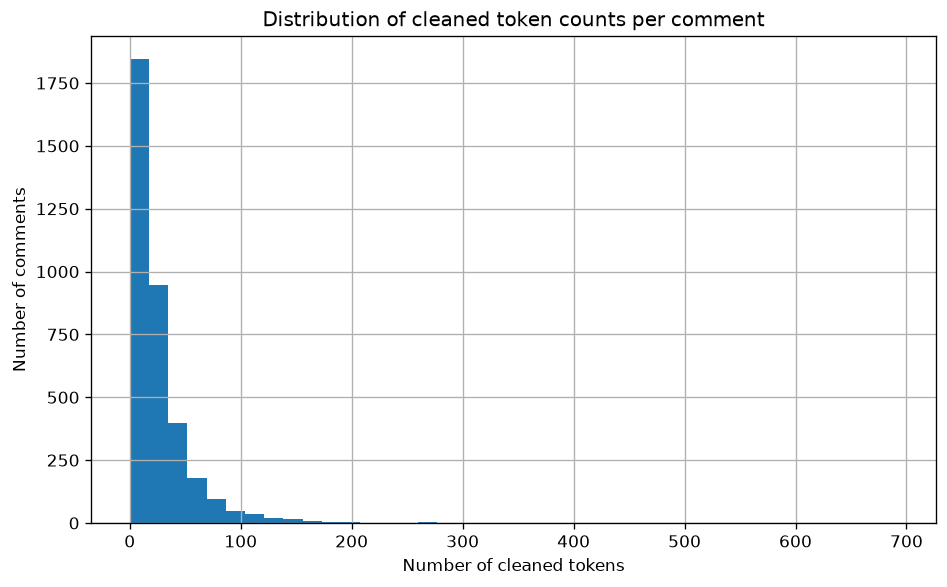

In [8]:
# Histogram of cleaned token counts per comment
ax = df['n_tokens_clean'].hist(bins=40)
ax.set_xlabel('Number of cleaned tokens')
ax.set_ylabel('Number of comments')
ax.set_title('Distribution of cleaned token counts per comment')
plt.tight_layout()
plt.show()

In [9]:
# Most common cleaned unigrams
all_toks = [t for row in df['tokens_clean'] for t in row]
cnt = Counter(all_toks)
top_cnt = pd.DataFrame(cnt.most_common(30), columns=['token','count'])
top_cnt.head(10)

,token,count
0,people,521
1,ai,519
2,code,501
3,time,439
4,google,396
5,work,360
6,using,331
7,good,297
8,need,283
9,things,279


In [10]:
# Most common bi-grams
def bigrams(lst):
    return list(zip(lst, lst[1:])) if len(lst) > 1 else []
all_bi = []
for row in df['tokens_clean']:
    all_bi.extend(bigrams(row))
bi_cnt = Counter(all_bi)
top_bi = pd.DataFrame([(f"{a} {b}", c) for (a,b), c in bi_cnt.most_common(30)], columns=['bigram','count'])
top_bi.head(10)

,bigram,count
0,claude code,94
1,web components,56
2,magic lantern,45
3,years ago,43
4,social credit,36
5,search engine,33
6,google search,32
7,cognitive decline,30
8,shadow dom,29
9,long time,24


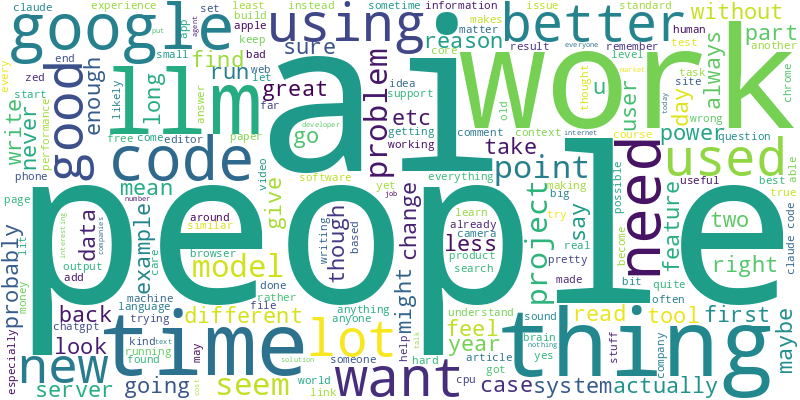

In [11]:
# Visualize with a wordcloud
wc = WordCloud(width=800, height=400, background_color='white')
text_blob = ' '.join(all_toks[:200000])  # cap for speed
img = wc.generate(text_blob).to_image()
display(img)

## Vectorization

For many applications and analyses, we will need to represent our text data in a numerical fashion, similar to producing a one-hot encoding for a categorical variable. *Term frequency* (TF) and *term frequency-inverse document frequency* (TF-IDF) vectors are two of the more common methods for vectorizing text data. 

A TF vector represents a document (in our case a single comment) as one vector with each position representing a word/token in our dataset. The value of each position for each document is the number of times that word shows up in that document (term frequency).

A TF-IDF vector is set up in the same way, but the value of each position is the number of times that word shows up in that document, divided by the number of documents that have the term.

These vectors are often combined into a single matrix for analysis, called a document-term matrix (since one axis will have the individual documents, and one axis will have the individual words).

**TODO**:
- Use scikit‑learn's `CountVectorizer` to create a TF document‑term matrix. This function has cleaning steps built into it, so we will apply the function to our `text-norm` column. Choose the appropriate settings to convert the text to lowercase, remove stopwords, ignore words that are in more than 95% of documents, and ignore words that are in fewer than 5 documents.
- Use scikit‑learn's `TfidfVectorizer` to create a TF-IDF document‑term matrix with the same cleaning settings as the TF matrix.

**Q**: What benefit do we get from using TF-IDF instead of the raw TF matrix?

**A**: TF-IDF down-weights terms that appear frequently across many documents (high document frequency) and up-weights terms that appear often within a specific document but are relatively rare across the corpus. This means common but semantically weak words — even those not in the stop-word list, like "people" or "time" — are automatically penalized, while rare but distinctive domain-specific or topic-specific terms receive higher scores. The result is a representation that better captures what is semantically unique about each document, which improves performance in downstream tasks like document similarity, clustering, and information retrieval compared to raw term counts.

**Q**: What differences do you see between the TF and TF-IDF top terms shown below?

**A**: The TF top terms for a given comment tend to be words that simply appear many times in that comment, but those words often also appear frequently throughout the entire corpus (e.g., "software", "code", "data"), making them less distinctive. The TF-IDF top terms shift toward words that are locally frequent but globally rare, so they better represent what is uniquely being discussed in that particular comment. In practice, TF-IDF surfaces more specific, topic-relevant vocabulary (technical terms, proper nouns, domain jargon) while suppressing the generic conversational words that dominate raw TF rankings.

In [12]:
cv = CountVectorizer(
    lowercase=True,
    stop_words='english',
    max_df=0.95,
    min_df=5
)
X_tf = cv.fit_transform(df['text_norm'].fillna(''))
vocab = np.array(cv.get_feature_names_out())
X_tf.shape, len(vocab)

((3607, 3195), 3195)

In [13]:
tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words='english',
    max_df=0.95,
    min_df=5
)
X_tfidf = tfidf.fit_transform(df['text_norm'].fillna(''))
tfidf_vocab = np.array(tfidf.get_feature_names_out())
X_tfidf.shape, len(tfidf_vocab)

((3607, 3195), 3195)

In [14]:
# Compare top tf anf tf-idf terms for a given doc
def top_terms(row_vector, vocab, k=10):
    row = row_vector.toarray().ravel()
    idx = row.argsort()[::-1][:k]
    return list(zip(vocab[idx], row[idx]))

# Show top terms for 3 random comments
for i in np.random.choice(X_tfidf.shape[0], size=3, replace=False):
    print(f"Doc {i} → top terms:")
    print("TF:")
    print(top_terms(X_tf[i], tfidf_vocab, k=10))
    print("TF-IDF:")
    print(top_terms(X_tfidf[i], tfidf_vocab, k=10))
    print('-'*60)

Doc 474 → top terms:
TF:
[('think', np.int64(1)), ('opinion', np.int64(1)), ('economic', np.int64(1)), ('power', np.int64(1)), ('russia', np.int64(1)), ('eyes', np.int64(0)), ('fails', np.int64(0)), ('failed', np.int64(0)), ('fail', np.int64(0)), ('factor', np.int64(0))]
TF-IDF:
[('economic', np.float64(0.5617977108225246)), ('russia', np.float64(0.5094494102747911)), ('opinion', np.float64(0.4778240403945093)), ('power', np.float64(0.35778567035109)), ('think', np.float64(0.2617598727798552)), ('eyes', np.float64(0.0)), ('fails', np.float64(0.0)), ('failed', np.float64(0.0)), ('fail', np.float64(0.0)), ('factor', np.float64(0.0))]
------------------------------------------------------------
Doc 756 → top terms:
TF:
[('reverse', np.int64(2)), ('engineering', np.int64(2)), ('wow', np.int64(1)), ('raw', np.int64(1)), ('work', np.int64(1)), ('honestly', np.int64(1)), ('project', np.int64(1)), ('seen', np.int64(1)), ('efforts', np.int64(1)), ('ve', np.int64(1))]
TF-IDF:
[('reverse', np.flo

## Sentiment Analysis
Sentiment analysis is used to produce a score for the "sentiment" of each document in your corpus. It is mosty frequently useful in applications in which you would like to understand the sentiment of a large corpus (e.g. are product reviews generally good or bad) or for segmenting a dataset for further analysis (e.g. within positive reviews, what topics are most common).

Like tokenization and vectorization, sentiment analysis methods range greatly in their complexity. For this analysis we will be applying a static lexicon (VADER) to our text, which maps each word in the dataset to a sentiment score. These scores are then combined to produce a single score for each document--positive values indicate a positive sentiment, and negative values indicate a negative sentiment.

**Q**: What do you notice about our distribution of sentiment scores? How would you expect this to change if we were looking at a dataset of Amazon product reviews?

**A**: The HackerNews comment sentiment distribution is roughly centered near zero and approximately bell-shaped, with a slight positive skew. This reflects the generally analytical, neutral, or measured tone of technical discussions on HackerNews — commenters tend to express opinions in nuanced, qualified language rather than strongly positive or negative terms, and many comments are primarily informational. For Amazon product reviews, we would expect a much more strongly right-skewed (positively skewed) distribution, concentrated at higher compound scores. This is because customers who take the time to review a product tend to feel positively about it, and the explicit five-star rating format encourages positive expression. Additionally, Amazon reviews are written in a more explicitly evaluative frame ("I love this product", "works great") that VADER's lexicon picks up readily, whereas HackerNews comments are more discursive and often use hedged or conditional language.

In [15]:
# Use the VADER sentiment lexicon to score our dataset
sia = SentimentIntensityAnalyzer()
scores = df['text_norm'].fillna('').apply(sia.polarity_scores)
df['sent_compound'] = scores.apply(lambda d: d['compound'])

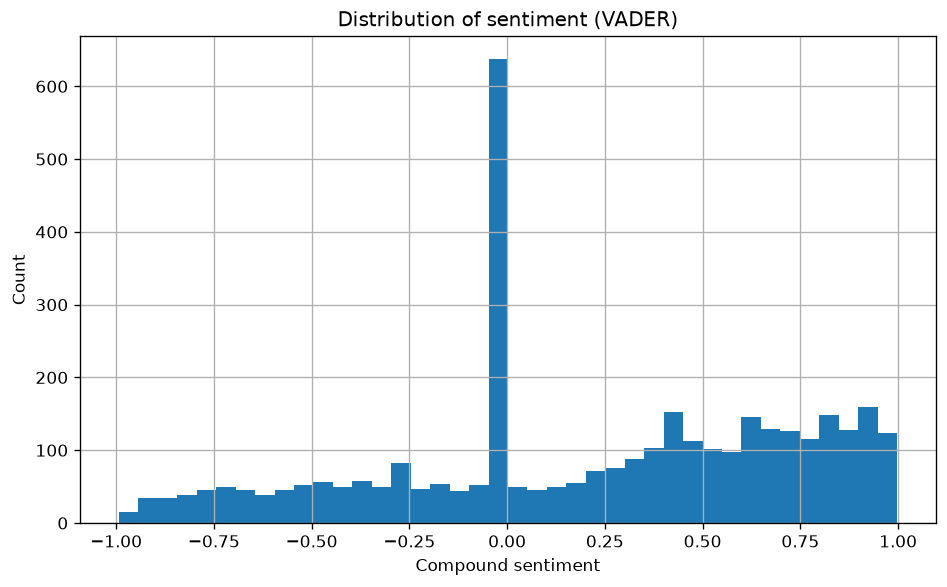

In [16]:
# Sentiment distribution
ax = df['sent_compound'].hist(bins=40)
ax.set_xlabel('Compound sentiment')
ax.set_ylabel('Count')
ax.set_title('Distribution of sentiment (VADER)')
plt.tight_layout()
plt.show()

## Save Engineered Features
We will save our modified dataset for future use.

In [17]:
features = df[['story_id','title','comment_id','user','text_norm','n_tokens_clean','sent_compound']].copy()
OUT_DIR = 'data/module2' ## TODO: Update file path as needed
os.makedirs(OUT_DIR, exist_ok=True)
OUT_CSV = os.path.join(OUT_DIR, 'hn_comment_features.csv')
features.to_csv(OUT_CSV, index=False)
OUT_CSV

'data/module2/hn_comment_features.csv'